### ASSIGNMENT No: 06

Title: To illustrate perceptron learning law with its decision regions 

Problem Statement: Implement perceptron learning law with its decision regions using python. Give the output in graphical form 

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 🔹 Perceptron Class
class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr = lr
        self.epochs = epochs
        
        # initialize weights
        self.w1 = 0
        self.w2 = 0
        self.b = 0

    # 🔹 Activation Function
    def activation(self, z):
        if z >= 0:
            return 1
        else:
            return -1

    # 🔹 Training Function
    def fit(self, X, y):
        for epoch in range(self.epochs):
            for i in range(len(X)):
                
                x1 = X[i][0]
                x2 = X[i][1]
                target = y[i]
                
                # weighted sum
                z = (self.w1 * x1) + (self.w2 * x2) + self.b
                
                # prediction
                y_pred = self.activation(z)
                
                # update if wrong
                if y_pred != target:
                    self.w1 += self.lr * target * x1
                    self.w2 += self.lr * target * x2
                    self.b += self.lr * target

    # 🔹 Prediction Function
    def predict(self, x1, x2):
        z = (self.w1 * x1) + (self.w2 * x2) + self.b
        return self.activation(z)

In [3]:
# 🔹 Function to Plot Decision Regions
def plot_decision_boundary(model, X, y):
    
    x_values = np.linspace(0, 8, 100)
    y_values = np.linspace(0, 8, 100)
    
    xx, yy = np.meshgrid(x_values, y_values)
    
    Z = model.w1 * xx + model.w2 * yy + model.b
    Z = np.where(Z >= 0, 1, -1)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    # plot points
    for i in range(len(X)):
        if y[i] == 1:
            plt.scatter(X[i][0], X[i][1], marker='o', label='Class 1' if i == 3 else "")
        else:
            plt.scatter(X[i][0], X[i][1], marker='x', label='Class -1' if i == 0 else "")
    
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Perceptron Decision Regions")
    plt.legend()
    plt.show()

In [4]:
# 🔹 Dataset
X = np.array([
    [2, 3],
    [4, 5],
    [1, 1],
    [2, 1],
    [6, 7],
    [7, 8]
])

In [5]:
y = np.array([-1, -1, -1, 1, 1, 1])

In [6]:
# 🔹 Create Model
model = Perceptron(lr=0.1, epochs=100)

In [7]:
# 🔹 Train Model
model.fit(X, y)

In [8]:
# 🔹 Print Results
print("Final Weights:", model.w1, model.w2)
print("Final Bias:", model.b)

Final Weights: 1.800000000000001 -1.3000000000000005
Final Bias: -1.0999999999999999


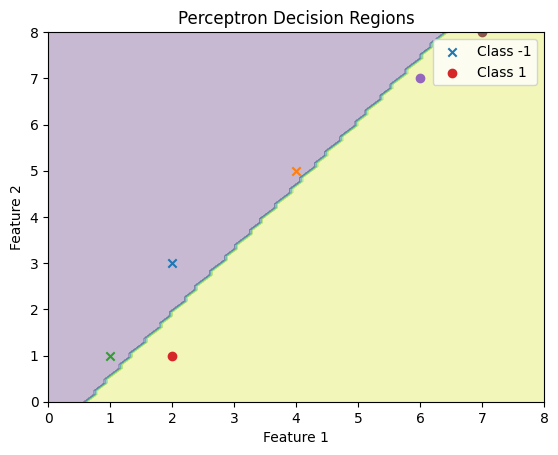

In [9]:
# 🔹 Plot
plot_decision_boundary(model, X, y)